# Kinematics across trials

In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [210]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

In [4]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [35]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [ ]:
# df = pyal.select_trials(df_, df_.trial_name == 'trial')
# df = dt.add_bhv(df_)
# df = dt.add_pca_df(df)
# df = kin.drop_immobile_trials_from_td(df, win=40, p=1, event_onset=(100, 200))


In [190]:
df.head()

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,MOp_spikes,all_rates,SSp_rates,VAL_rates,GPe_rates,CP_rates,MOp_rates,sol_level_id,sol_contra_ipsi,bhv
0,M061,M061_2025_03_06_14_00,2,trial,600,0.01,60500,61099,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.093070924, 0.0, 0.0, 15.6925535, 0.4696169...","[[8.749083, 0.0, 15.5882435, 0.0, 0.0, 0.0, 0....","[[0.2762286, 32.52908, 0.0013355394, 7.811231,...","[[53.410454, 10.727865, 66.73731, 0.0, 0.0, 51...","[[29.476328, 53.33859, 23.22654, 29.499859, 8....","[[32.81393, 0.0, 9.317302, 0.7749599, 0.0, 0.0...",0.0,0.0,"[[-8.308413052944957, 11.259493161075184, 217...."
1,M061,M061_2025_03_06_14_00,4,trial,600,0.01,61200,61799,[],[],...,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 5.5446486, 0.0, 0.0, 0.0...","[[0.27375525, 0.0, 0.0, 3.9031663, 0.0, 0.0, 0...","[[24.443327, 15.181539, 0.1257371, 31.301853, ...","[[48.039776, 26.062391, 34.26858, 0.0, 0.0, 46...","[[0.23629218, 46.143555, 33.883762, 17.946896,...","[[19.438744, 0.0, 26.681507, 0.0, 0.0, 0.0, 0....",1.0,0.0,"[[-6.609595859201188, 11.812341121485844, 218...."
2,M061,M061_2025_03_06_14_00,6,trial,600,0.01,62300,62899,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[36.172363, 0.0, 0.0, 24.762882, 25.877794, 0...","[[15.7517, 4.8779242e-05, 0.0, 0.0, 0.00474381...","[[16.315289, 52.443726, 18.065641, 0.0, 0.0003...","[[46.300278, 15.6517105, 53.41636, 0.0, 0.0, 6...","[[0.0021536883, 60.416218, 28.896454, 10.49675...","[[15.0233135, 0.0, 1.5043623, 0.0, 0.0, 0.0, 0...",1.0,0.0,"[[-5.319521453932582, 10.00921406311837, 211.2..."
3,M061,M061_2025_03_06_14_00,8,trial,600,0.01,63400,63999,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.00089810096, 0.0, 0.000521073, 0.0, 0...","[[15.566815, 0.026170593, 0.0, 0.0, 0.0, 0.0, ...","[[27.833752, 33.456306, 27.930204, 43.580418, ...","[[24.143513, 3.9129512, 35.868313, 0.0, 0.0, 1...","[[2.005567, 33.85045, 27.861921, 39.591812, 0....","[[1.5041213, 0.0, 10.553282, 0.0, 0.0, 0.0, 0....",0.0,1.0,"[[-7.101308457078938, 10.883064750144056, 211...."
4,M061,M061_2025_03_06_14_00,10,trial,600,0.01,64500,65099,[],[],...,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0022323057, 0.0, 0.0, 54.192406, 1.3178213...","[[4.8779242e-05, 4.8779242e-05, 0.0, 0.0, 0.27...","[[14.679855, 17.06383, 10.602128, 37.506157, 1...","[[34.104385, 36.875553, 38.693394, 0.0, 0.0, 4...","[[2.2660065, 69.31302, 33.853176, 28.293697, 0...","[[42.28235, 0.0, 10.449963, 0.0021049092, 0.0,...",1.0,0.0,"[[-2.4080383315543563, 11.802780313638689, 215..."


In [246]:
def compute_peak_freq_pre_perturb(bhv_arr, nperseg=None, noverlap=None):
    freqs, psd = scipy.signal.welch(
        bhv_arr, fs=100, nperseg=nperseg, noverlap=noverlap, axis=0
    )
    return freqs[np.argmax(psd, axis=0)]

bhv_field = 'left_knee'
powers = []
for bhv_field in ['left_knee', 'right_knee']:
    # bhv_arr = np.concatenate([df[bhv_field].values[1], df[bhv_field].values[2]])[:, -1]
    bhv_arr = df[bhv_field].values[3][:, 2]
    peak_freq = compute_peak_freq_pre_perturb(bhv_arr)
    print(peak_freq)
    power = dsp.get_power_in_freq_range(bhv_arr, fs=100, freqs=(peak_freq - 0.5, peak_freq + 1))
    powers.append(power)

powers = np.array(powers)

7.0
7.0


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 100, using nperseg = 100
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 100, using nperseg = 100
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


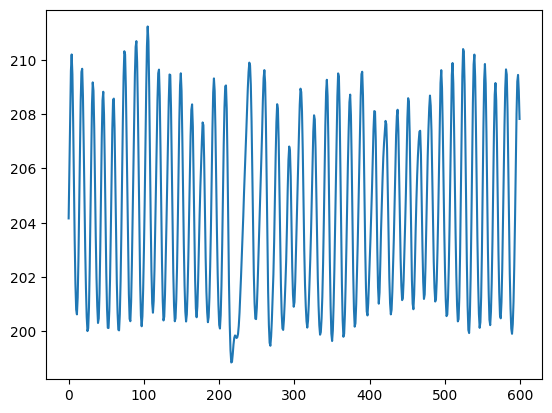

In [207]:
plt.plot(bhv_arr)

In [236]:
i = 2
np.concatenate([df_.iloc[i-1]['left_knee'][:, 2], df_.iloc[i]['left_knee'][:, 2]]).shape

(1100,)

In [274]:
def concat_bhv(df, col=['left_knee', 'right_knee'], new_col='bhv_concat', dim_=2):
    df = df.copy()
    df[new_col] = pd.Series([None] * len(df), dtype="object")
    df["concat_perturb_time"] = pd.Series([None] * len(df), dtype="object")

    n = len(df)

    # IMPORTANT: iterate by POSITION so df.iloc[pos±1] is always valid
    for pos in range(n):
        row = df.iloc[pos]
        if row.trial_name != "trial":
            continue
        if pos == 0 or pos == n - 1:
            continue

        def as_time_x_features(r):
            # each r[c] assumed shape (T, D); take one dim -> (T,)
            return np.column_stack([np.asarray(r[c])[:, dim_] for c in col])  # (T, n_features)

        prev_tf = as_time_x_features(df.iloc[pos - 1])  # (T, n_features)
        curr_tf = as_time_x_features(df.iloc[pos])      # (T, n_features)
        next_tf = as_time_x_features(df.iloc[pos + 1])  # (T, n_features)

        df.at[df.index[pos], new_col] = np.concatenate([prev_tf, curr_tf, next_tf], axis=0)  # (3T, n_features)
        df.at[df.index[pos], "concat_perturb_time"] = df.iloc[pos - 1].trial_length + 200

    return df


df = concat_bhv(df_)

In [275]:
df.bhv_concat.values[2].shape

(1200, 2)

In [268]:
df[:10]

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,SSp_rates,VAL_rates,GPe_rates,CP_rates,MOp_rates,sol_level_id,sol_contra_ipsi,bhv,bhv_concat,concat_perturb_time
0,M061,M061_2025_03_06_14_00,0,free,60000,0.01,0,59999,[],1.0,...,"[[0.0, 8.749083, 0.00012739658, 0.0, 0.0102808...","[[1.8788582, 33.536736, 1.7400755, 12.799794, ...","[[59.259827, 31.873262, 22.325476, 0.0, 0.0, 2...","[[0.0, 49.28063, 15.566815, 33.043465, 0.08489...","[[0.0, 0.0, 2.1744087, 0.0, 2.7606552, 0.0, 0....",NaN,NaN,"[[-8.714492970827468, 10.93552004149664, 210.6...",None,None
1,M061,M061_2025_03_06_14_00,1,intertrial,500,0.01,60000,60499,[],[],...,"[[11.071746, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[[12.006422, 60.700893, 56.523605, 15.566815, ...","[[16.287483, 43.7697, 29.880617, 0.0, 0.0, 116...","[[0.0, 54.803707, 3.2647038, 7.2447352, 0.0, 0...","[[0.0, 2.7606552, 51.021427, 0.0, 28.884914, 0...",NaN,NaN,"[[-7.434137154566039, 12.663991014755114, 220....",None,None
2,M061,M061_2025_03_06_14_00,2,trial,600,0.01,60500,61099,[],[],...,"[[8.749083, 0.0, 15.5882435, 0.0, 0.0, 0.0, 0....","[[0.2762286, 32.52908, 0.0013355394, 7.811231,...","[[53.410454, 10.727865, 66.73731, 0.0, 0.0, 51...","[[29.476328, 53.33859, 23.22654, 29.499859, 8....","[[32.81393, 0.0, 9.317302, 0.7749599, 0.0, 0.0...",0.0,0.0,"[[-8.308413052944957, 11.259493161075184, 217....","[210.9137619399828, 208.86158634667865, 206.92...",700
3,M061,M061_2025_03_06_14_00,3,intertrial,100,0.01,61100,61199,[],[],...,"[[0.0021049092, 0.04294701, 0.0, 0.0, 4.877924...","[[11.712245, 36.027554, 0.0, 36.17494, 3.65789...","[[27.50342, 2.4325833, 41.87799, 0.0, 0.0, 57....","[[0.021426776, 69.542, 11.996277, 39.527187, 0...","[[2.7820818, 0.0, 15.80465, 0.0, 0.0, 0.0, 0.0...",NaN,NaN,"[[-9.227197615255614, 11.519285976490409, 213....",None,None
4,M061,M061_2025_03_06_14_00,4,trial,600,0.01,61200,61799,[],[],...,"[[0.27375525, 0.0, 0.0, 3.9031663, 0.0, 0.0, 0...","[[24.443327, 15.181539, 0.1257371, 31.301853, ...","[[48.039776, 26.062391, 34.26858, 0.0, 0.0, 46...","[[0.23629218, 46.143555, 33.883762, 17.946896,...","[[19.438744, 0.0, 26.681507, 0.0, 0.0, 0.0, 0....",1.0,0.0,"[[-6.609595859201188, 11.812341121485844, 218....","[206.8606672779244, 208.2660421919753, 209.279...",300
5,M061,M061_2025_03_06_14_00,5,intertrial,500,0.01,61800,62299,[],[],...,"[[12.2605, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[18.51603, 52.281567, 22.71725, 28.421453, 0....","[[46.858177, 10.597, 53.921318, 0.0, 0.0, 63.9...","[[3.1095927, 48.11395, 15.290167, 25.426794, 0...","[[16.036482, 0.0, 17.859201, 12.363018, 0.0, 0...",NaN,NaN,"[[-6.401065135296863, 11.42383554541107, 207.6...",None,None
6,M061,M061_2025_03_06_14_00,6,trial,600,0.01,62300,62899,[],[],...,"[[15.7517, 4.8779242e-05, 0.0, 0.0, 0.00474381...","[[16.315289, 52.443726, 18.065641, 0.0, 0.0003...","[[46.300278, 15.6517105, 53.41636, 0.0, 0.0, 6...","[[0.0021536883, 60.416218, 28.896454, 10.49675...","[[15.0233135, 0.0, 1.5043623, 0.0, 0.0, 0.0, 0...",1.0,0.0,"[[-5.319521453932582, 10.00921406311837, 211.2...","[200.07289867245223, 198.5643867153727, 198.48...",700
7,M061,M061_2025_03_06_14_00,7,intertrial,500,0.01,62900,63399,[],[],...,"[[0.27375525, 0.27375525, 0.0, 0.0, 1.8788582,...","[[27.461353, 50.43591, 0.0, 21.534988, 0.0, 0....","[[25.756746, 38.051884, 17.427994, 0.0, 0.0, 3...","[[10.606872, 45.844704, 8.548958, 21.624792, 4...","[[21.122381, 0.0, 12.385344, 0.0, 0.0, 0.0, 0....",NaN,NaN,"[[-5.767887352970411, 11.828711634117491, 215....",None,None
8,M061,M061_2025_03_06_14_00,8,trial,600,0.01,63400,63999,[],[],...,"[[15.566815, 0.026170593, 0.0, 0.0, 0.0, 0.0, ...","[[27.833752, 33.456306, 27.930204, 43.580418, ...","[[24.143513, 3.9129512, 35.868313, 0.0, 0.0, 1...","[[2.005567, 33.85045, 27.861921, 39.591812, 0....","[[1.5041213, 0.0, 10.553282, 0.0, 0.0, 0.0, 0....",0.0,1.0,"[[-7.101308457078938, 10.883064750144056, 211....","[207.46950738193823, 208.3915

In [277]:
df.bhv_concat.values[6].shape

(1600, 2)

In [278]:
def compute_peak_freq_pre_perturb(bhv_arr, perturb_idx: int, nperseg=None, noverlap=None):
    freqs, psd = scipy.signal.welch(
        bhv_arr[:perturb_idx], fs=100, nperseg=nperseg, noverlap=noverlap, axis=0
    )
    return freqs[np.argmax(psd, axis=0)]

In [289]:
bhv_field = 'left_knee'
powers = []
peak_freqs = compute_peak_freq_pre_perturb(df.bhv_concat.values[2], perturb_idx=df.concat_perturb_time.values[2])
for i, peak_freq in enumerate(peak_freqs):
    power = dsp.get_power_in_freq_range(df.bhv_concat.values[2][:, i], fs=100, freqs=(peak_freq - 1, peak_freq + 1))
    powers.append(power)

powers = np.array(powers)

In [291]:
powers.shape

(2, 1200)

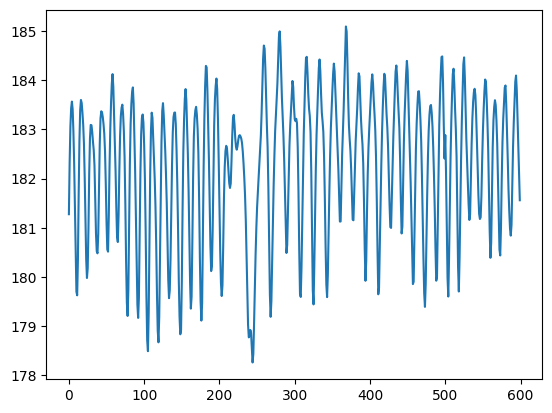

In [397]:
plt.plot(df.left_elbow.values[0][:, 2])

d: 1.104
Bimodal: False
Thresh: 16.59
Dropped 18 of 333 rows (5.41%).


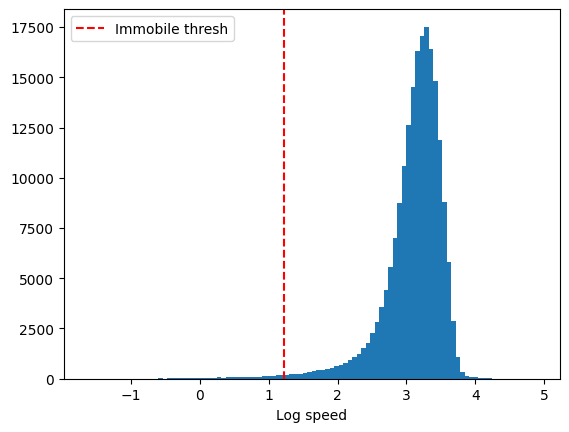

In [404]:
df = concat_bhv(df_, col=('left_knee', 'right_knee'))
df = pyal.select_trials(df, df.trial_name == 'trial')
df = kin.drop_immobile_trials_from_td(df, p=1)

In [405]:
def compute_power_in_td(df):
    powers = []
    total_trials = len(df)
    n = 0
    for _, row in df.iterrows():
        peak_freqs = compute_peak_freq_pre_perturb(row.bhv_concat, perturb_idx=row.concat_perturb_time)
        _powers = []
        if any(x < 0.5 for x in peak_freqs):
            n = n + 1
            continue

        for i, peak_freq in enumerate(peak_freqs):
            power = dsp.get_power_in_freq_range(row.bhv_concat[:, i], fs=100, freqs=(peak_freq - 0.5, peak_freq + 1))
            _powers.append(power[(row.concat_perturb_time - 200):(row.concat_perturb_time + 400)])
        _powers = np.array(_powers)
        powers.append(_powers)

    powers = np.array(powers)
    print(f"Dropped {n} trials {(n / total_trials) * 100:.2f}")
    return powers

powers = compute_power_in_td(df)

Dropped 45 trials 14.29


In [400]:
powers.shape

(293, 2, 600)

Text(0.5, 1.0, 'Right and left knee')

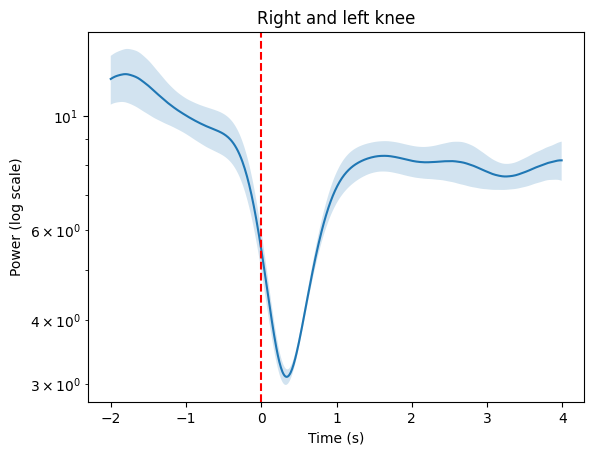

In [416]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, np.arange(-2, 4, 0.01), powers.mean(axis=0).T)
ax.axvline(0, color='red', linestyle='dashed')
# ax.set_xlim(15, 1200)

ax.set_yscale("log")
ax.set_ylabel("Power (log scale)")
ax.set_xlabel("Time (s)")
ax.set_title('Right and left knee')